### Importing all necessary libraries

In [ ]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
# Modelling
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

### Reading dataset

In [4]:
df = pd.read_csv("data/stud.csv")

In [5]:
df.head(2)

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88


### Separating independent and dependent features

In [6]:
X = df.drop("math_score",axis=1)
y = df["math_score"]

In [8]:
X

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75
...,...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,99,95
996,male,group C,high school,free/reduced,none,55,55
997,female,group C,high school,free/reduced,completed,71,65
998,female,group D,some college,standard,completed,78,77


In [9]:
y

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math_score, Length: 1000, dtype: int64

### Applying standard scaling and one hot encoding 

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

num_features = [feature for feature in X.columns if df[feature].dtype!="str"]
cat_features = [feature for feature in X.columns if df[feature].dtype=="str" ]

print(f"numerical features = {num_features}")
print(f"categorical features = {cat_features}")

numerical features = ['reading_score', 'writing_score']
categorical features = ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


In [11]:
ohe = OneHotEncoder(drop="first")
sc = StandardScaler()

from sklearn.compose import ColumnTransformer

ct = ColumnTransformer(transformers=[("onehotencoder",ohe,cat_features),("standardscaler",sc,num_features)])
X = ct.fit_transform(X)

In [12]:
X

array([[ 0.        ,  1.        ,  0.        , ...,  1.        ,
         0.19399858,  0.39149181],
       [ 0.        ,  0.        ,  1.        , ...,  0.        ,
         1.42747598,  1.31326868],
       [ 0.        ,  1.        ,  0.        , ...,  1.        ,
         1.77010859,  1.64247471],
       ...,
       [ 0.        ,  0.        ,  1.        , ...,  0.        ,
         0.12547206, -0.20107904],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.60515772,  0.58901542],
       [ 0.        ,  0.        ,  0.        , ...,  1.        ,
         1.15336989,  1.18158627]], shape=(1000, 14))

### Splitting the data into train and test set

In [13]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=1)

In [14]:
x_train.shape

(800, 14)

In [15]:
x_test.shape

(200, 14)

### Creating an evaluate function to give all metrics after training

In [16]:
def evaluate_model(y_test,y_pred):
    r2 = r2_score(y_test,y_pred)
    mse = mean_squared_error(y_test,y_pred)
    mae = mean_absolute_error(y_test,y_pred)
    rmse = np.sqrt(mse)
    return r2,mse,mae,rmse

### Model training

In [20]:
models = {
    "linear regression":LinearRegression(),
    "Ridge regression":Ridge(),
    "Lasso regression":Lasso(),
    "k Neighbors":KNeighborsRegressor(),
    "decision tree regressor":DecisionTreeRegressor(),
    "random forest regressor":RandomForestRegressor(),
    "adaboost regressor":AdaBoostRegressor(),
    "support vector regressor":SVR(),
    "catboost regressor":CatBoostRegressor(verbose=False),
    "XG boost regressor":XGBRegressor()
}

In [21]:
model_list = []
r2_list = []
for name,model in models.items():
    model.fit(x_train,y_train)
    y_pred = model.predict(x_test)

    r2,mse,mae,rmse = evaluate_model(y_test,y_pred)

    print(f"{name}")
    print(f"r2 score = {r2}")
    print(f"mean squared error = {mse}")
    print(f"mean absolute error = {mae}")
    print(f"root mean squared error = {rmse}")
    print("-----------")
    print()

    model_list.append(name)
    r2_list.append(r2)


linear regression
r2 score = 0.8954807540309733
mean squared error = 25.65265761757772
mean absolute error = 3.989814611743902
root mean squared error = 5.064845270842706
-----------

Ridge regression
r2 score = 0.895430245516525
mean squared error = 25.665054163456944
mean absolute error = 3.9883438172975136
root mean squared error = 5.066068906307626
-----------

Lasso regression
r2 score = 0.8297064952059504
mean squared error = 41.79594803308898
mean absolute error = 5.093528853464245
root mean squared error = 6.464978579476423
-----------

k Neighbors
r2 score = 0.8135936523257554
mean squared error = 45.750600000000006
mean absolute error = 5.407
root mean squared error = 6.76391898236518
-----------

decision tree regressor
r2 score = 0.7114712045185936
mean squared error = 70.815
mean absolute error = 6.705
root mean squared error = 8.415164882520127
-----------

random forest regressor
r2 score = 0.8579789114886928
mean squared error = 34.85691390402778
mean absolute error = 4

### Observation : Linear regression model is performing best


## Results

In [23]:
results = pd.DataFrame(list(zip(model_list,r2_list)),columns=["model name","r2 score"]).sort_values(by="r2 score",ascending=False)

In [24]:
results

,model name,r2 score
0,linear regression,0.895481
1,Ridge regression,0.895430
8,catboost regressor,0.870282
5,random forest regressor,0.857979
6,adaboost regressor,0.841963
9,XG boost regressor,0.831772
2,Lasso regression,0.829706
3,k Neighbors,0.813594
7,support vector regressor,0.751312
4,decision tree regressor,0.711471


### Training Linear regression model


In [26]:
lr = LinearRegression()
lr.fit(x_train,y_train)
y_pred = lr.predict(x_test)
score = r2_score(y_test,y_pred)*100
print(f"r2 score = {score:.2f}")

r2 score = 89.55


### Visualising actual and predicted results

Text(0, 0.5, 'Predicted results')

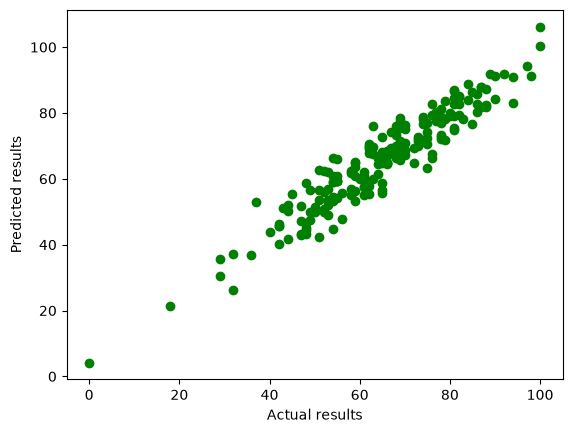

In [33]:
plt.scatter(y_test,y_pred,color="green")
plt.xlabel("Actual results")
plt.ylabel("Predicted results")

### Observation: The points and distributed linearly which means our model is good

<Axes: xlabel='math_score'>

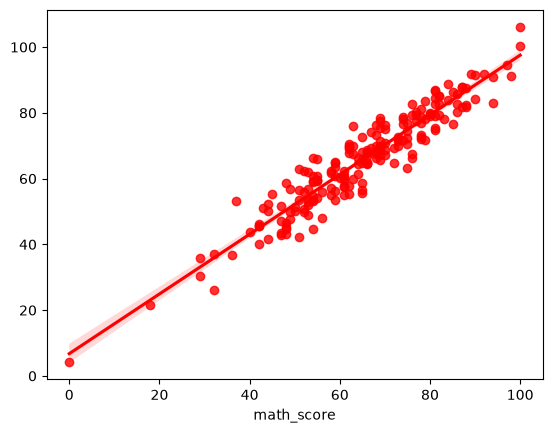

In [34]:
sns.regplot(x=y_test,y=y_pred,color="red")

### Difference between actual and predicted values

In [36]:
difference = pd.DataFrame({"actual_results":y_test,"predicted_result":y_pred,"difference":y_test-y_pred},index=None)
difference

,actual_results,predicted_result,difference
507,55,59.472217,-4.472217
818,60,60.046971,-0.046971
452,65,64.678172,0.321828
368,44,50.288076,-6.288076
242,56,47.891434,8.108566
...,...,...,...
430,64,64.542349,-0.542349
874,43,51.179110,-8.179110
550,79,71.772673,7.227327
608,61,60.946937,0.053063
